# Exploratory Data Analysis

   ## Project Overview
   This solo project aims to analyze the biggest factors when it comes to increasing the chance of winning a League of Legends ranked game.

In [112]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('data/games.csv')

# Basic data info
print(f"Dataset shape: {df.shape}")
print(f"Column names: {df.columns.to_list()}")
df.head()

Dataset shape: (51490, 61)
Column names: ['gameId', 'creationTime', 'gameDuration', 'seasonId', 'winner', 'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon', 'firstRiftHerald', 't1_champ1id', 't1_champ1_sum1', 't1_champ1_sum2', 't1_champ2id', 't1_champ2_sum1', 't1_champ2_sum2', 't1_champ3id', 't1_champ3_sum1', 't1_champ3_sum2', 't1_champ4id', 't1_champ4_sum1', 't1_champ4_sum2', 't1_champ5id', 't1_champ5_sum1', 't1_champ5_sum2', 't1_towerKills', 't1_inhibitorKills', 't1_baronKills', 't1_dragonKills', 't1_riftHeraldKills', 't1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5', 't2_champ1id', 't2_champ1_sum1', 't2_champ1_sum2', 't2_champ2id', 't2_champ2_sum1', 't2_champ2_sum2', 't2_champ3id', 't2_champ3_sum1', 't2_champ3_sum2', 't2_champ4id', 't2_champ4_sum1', 't2_champ4_sum2', 't2_champ5id', 't2_champ5_sum1', 't2_champ5_sum2', 't2_towerKills', 't2_inhibitorKills', 't2_baronKills', 't2_dragonKills', 't2_riftHeraldKills', 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', '

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,...,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,...,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,...,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,...,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,...,3,0,0,1,0,86,11,201,122,18


In [113]:
print("Basic description of all of the features:")

# We store the creation time for later maybe
creation_time_col = df['creationTime']
df = df.drop(['gameId', 'creationTime', 'seasonId'], axis=1)

# Detecting any null values in features
null_counts = df.isna().sum()
if (null_counts == 0).all():
    print("- No null values found in any feature.")
else:
    print(f"- Features with null values:\n{null_counts[null_counts > 0]}")
    
# Checking data types
print(f"- Unique data types in the dataset: {(df.dtypes.unique())}")

df.describe()

Basic description of all of the features:
- No null values found in any feature.
- Unique data types in the dataset: [dtype('int64')]


,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,...,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000
mean,1832.362808,1.493552,1.471295,1.450631,1.308487,0.926510,1.442804,0.731676,114.293397,6.601787,...,5.549466,0.985084,0.414547,1.404370,0.240105,108.216294,107.910216,108.690581,108.626044,108.066576
std,512.017696,0.499963,0.520326,0.542848,0.676097,0.841424,0.569579,0.822526,119.000867,4.025601,...,3.860989,1.256284,0.613768,1.224492,0.427151,102.551787,102.870710,102.592145,103.346952,102.756149
min,190.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1531.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,35.000000,4.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,38.000000,37.000000,38.000000,38.000000,38.000000
50%,1833.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,79.000000,4.000000,...,6.000000,0.000000,0.000000,1.000000,0.000000,90.000000,90.000000,90.000000,90.000000,90.000000
75%,2148.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,136.000000,11.000000,...,9.000000,2.000000,1.000000,2.000000,0.000000,141.000000,141.000000,141.000000,141.000000,141.000000
max,4728.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,516.000000,21.000000,...,11.000000,10.000000,4.000000,6.000000,1.000000,516.000000,516.000000,516.000000,516.000000,516.000000


We saw that the dataset includes only one datatype int64 and contains no null values.
Now we generate histogram plots for the continuous features to show the distribution of them.
Although some features like herald kills or baron kills can be considered continuous the amounts are too small.
I will not plot features with 'first' in their name because they have 3 unique values.
I also dropped champion picks/bans and summoner spell picks since i will make interactive plots for them later.


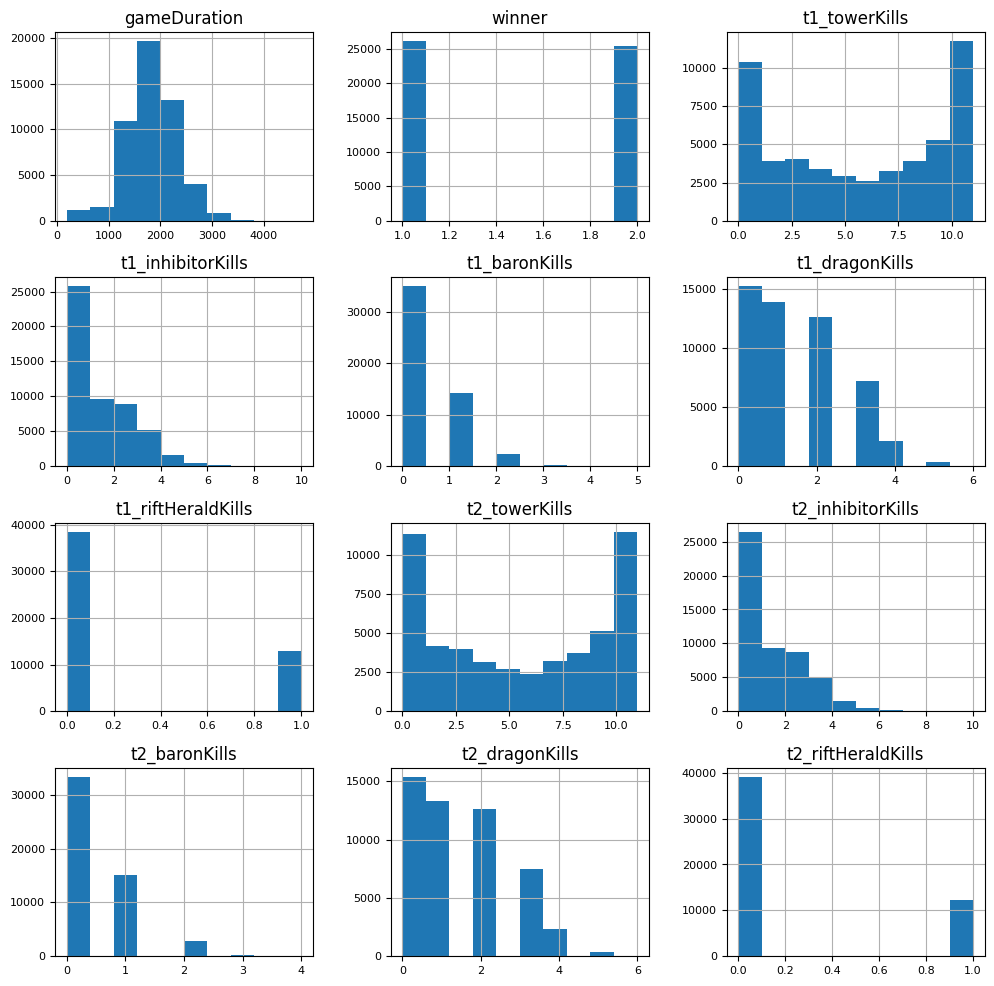

In [ ]:
print("We saw that the dataset includes only one datatype int64 and contains no null values.")
print("Now we generate histogram plots for the continuous features to show the distribution of them.")
print("Although some features like herald kills or baron kills can be considered continuous the amounts are too small.")
print("I will not plot features with 'first' in their name because they have 3 unique values.")
print("I also dropped champion picks/bans and summoner spell picks since i will make interactive plots for them later.")

# Generating the list of columns to drop
cols_to_drop = []

for team in [1, 2]:
    for i in range(1, 6):
        cols_to_drop.append(f't{team}_champ{i}id')
        cols_to_drop.append(f't{team}_ban{i}')
        for sum in [1, 2]:
            cols_to_drop.append(f't{team}_champ{i}_sum{sum}')

# Store first event columns for evaluation later
events = ['Blood', 'Tower', 'Inhibitor', 'Baron', 'Dragon', 'RiftHerald']
first_events_cols = [f'first{event}' for event in events]

hist_df = df.drop(cols_to_drop, axis=1)
hist_df = hist_df.drop(first_events_cols, axis=1)

# continuous_features = hist_df.nunique()[df.nunique() > 3]
# hist_df = hist_df[continuous_features.index.tolist()]
hist_df.hist(figsize=(12, 12), xlabelsize=8, ylabelsize=8);
